# Comparación LSTM vs GRU — Predicción de Series Temporales
## Caso de Estudio: Cotización USD → BRL

| # | Sección |
|---|---|
| 1 | Importación de librerías y carga del dataset |
| 2 | Normalización y ventanas deslizantes |
| 3 | División cronológica y DataLoaders |
| 4 | Pipeline de entrenamiento compartido |
| 5 | Modelo LSTM |
| 6 | Modelo GRU |
| 7 | Evaluación desnormalizada en BRL |
| 8 | Gráfica comparativa |
| 9 | Tabla de resultados finales |

## 1. Importación de Librerías y Carga del Dataset

In [84]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
from tqdm import tqdm

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

print('Librerías cargadas correctamente.')
print(f'PyTorch versión : {torch.__version__}')
print(f'Dispositivo     : {"cuda" if torch.cuda.is_available() else "cpu"}')

Librerías cargadas correctamente.
PyTorch versión : 2.5.1
Dispositivo     : cuda


In [85]:
ruta_csv = r'D:\2026\IA-2026-DATASETS\USD_BRL Historical Data.csv'

df = pd.read_csv(ruta_csv)
df = df[['Date', 'Price']]
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)

if df['Price'].dtype == 'object':
    df['Price'] = df['Price'].str.replace(',', '').astype(float)

print(f'Registros totales : {len(df)}')
print(f'Rango de fechas   : {df["Date"].min().date()} -> {df["Date"].max().date()}')
print(f'Precio min / max  : {df["Price"].min():.4f} / {df["Price"].max():.4f} BRL')
df.head()

Registros totales : 2922
Rango de fechas   : 2015-01-01 -> 2026-03-13
Precio min / max  : 2.5722 / 6.2896 BRL


,Date,Price
0,2015-01-01,2.6570
1,2015-01-02,2.6931
2,2015-01-05,2.7059
3,2015-01-06,2.6996
4,2015-01-07,2.6830


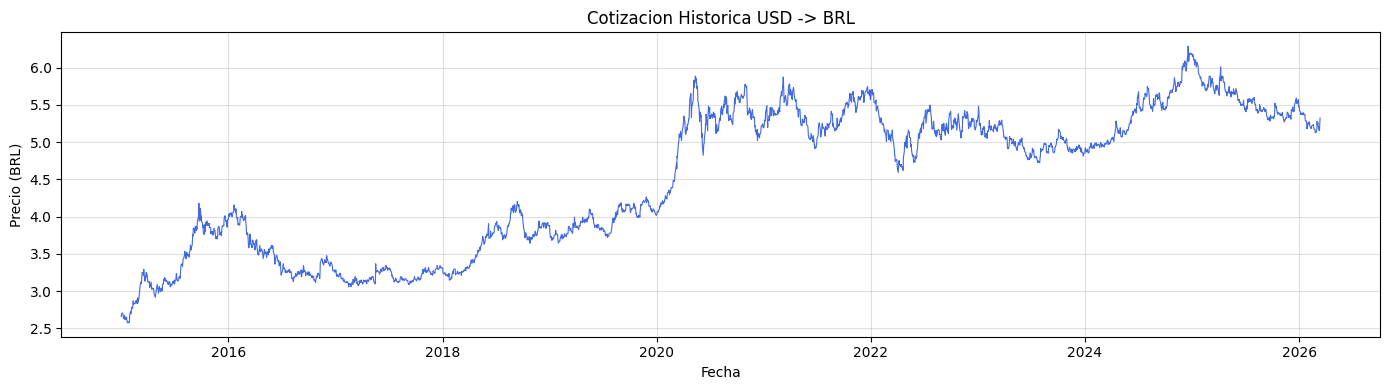

In [86]:
plt.figure(figsize=(14, 4))
plt.plot(df['Date'], df['Price'], color='royalblue', linewidth=0.8)
plt.title('Cotizacion Historica USD -> BRL')
plt.xlabel('Fecha'); plt.ylabel('Precio (BRL)')
plt.grid(True, alpha=0.4); plt.tight_layout(); plt.show()

## 2. Normalización y Ventanas Deslizantes

> **Regla de corrección de escala:** el `MinMaxScaler` se ajusta sobre los precios originales en BRL. En la evaluación, `scaler.inverse_transform()` revierte las predicciones [0,1] de vuelta a BRL para calcular MSE y RMSE en la escala real.

In [87]:
n_steps   = 20
n_out      = 10
batch_size = 64

# MinMaxScaler ajustado sobre precios en BRL — se reutiliza en evaluacion
precios_raw  = df['Price'].values.reshape(-1, 1)
scaler       = MinMaxScaler(feature_range=(0, 1))
precios_norm = scaler.fit_transform(precios_raw).flatten()

print(f'Rango normalizado : [{precios_norm.min():.4f}, {precios_norm.max():.4f}]')
print(f'Scaler min_       : {scaler.data_min_[0]:.4f} BRL')
print(f'Scaler max_       : {scaler.data_max_[0]:.4f} BRL')


def crear_ventanas(serie, n_steps, n_out=10):
    """
    Convierte una serie 1D normalizada en ventanas para LSTM/GRU.
    X : (N, n_steps, 1)   <- tensor 3D requerido por nn.LSTM y nn.GRU
    y : (N, n_out)        <- los proximos n_out valores a predecir
    """
    X, y = [], []
    for i in range(len(serie) - n_steps - n_out + 1):
        X.append(serie[i : i + n_steps])
        y.append(serie[i + n_steps : i + n_steps + n_out])
    X = np.array(X, dtype=np.float32)[:, :, np.newaxis]  # anadir dim feature
    y = np.array(y, dtype=np.float32)                     # (N, n_out)
    return X, y


X_all, y_all = crear_ventanas(precios_norm, n_steps, n_out)
print(f'\nX_all : {X_all.shape}  -> (muestras, n_steps, features)')
print(f'y_all : {y_all.shape}  -> (muestras, N_OUT)  [salida multi-paso]')


Rango normalizado : [0.0000, 1.0000]
Scaler min_       : 2.5722 BRL
Scaler max_       : 6.2896 BRL

X_all : (2893, 20, 1)  -> (muestras, n_steps, features)
y_all : (2893, 10)  -> (muestras, N_OUT)  [salida multi-paso]


## 3. Division Cronologica y DataLoaders

In [88]:
n_total = len(X_all)
n_train = int(n_total * 0.70)
n_val   = int(n_total * 0.15)

X_train, y_train = X_all[:n_train],              y_all[:n_train]
X_val,   y_val   = X_all[n_train:n_train+n_val], y_all[n_train:n_train+n_val]
X_test,  y_test  = X_all[n_train+n_val:],        y_all[n_train+n_val:]

print(f'Train : {X_train.shape[0]:>5} muestras  X={X_train.shape}')
print(f'Val   : {X_val.shape[0]:>5} muestras  X={X_val.shape}')
print(f'Test  : {X_test.shape[0]:>5} muestras  X={X_test.shape}')


class TimeSeriesDataset(Dataset):
    """Dataset generico para LSTM/GRU — entrada 3D (n_steps, 1)."""
    def __init__(self, X, y=None):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32) if y is not None else None

    def __len__(self):  return len(self.X)

    def __getitem__(self, ix):
        return (self.X[ix], self.y[ix]) if self.y is not None else self.X[ix]


dataloader = {
    'train': DataLoader(TimeSeriesDataset(X_train, y_train), shuffle=True,  batch_size=batch_size),
    'eval' : DataLoader(TimeSeriesDataset(X_val,   y_val),   shuffle=False, batch_size=batch_size),
    'test' : DataLoader(TimeSeriesDataset(X_test),            shuffle=False, batch_size=batch_size),
}

Xb, yb = next(iter(dataloader['train']))
print(f'\nBatch X : {Xb.shape}  -> (batch, n_steps, features)')
print(f'Batch y : {yb.shape}  -> (batch, 10)')

Train :  2025 muestras  X=(2025, 20, 1)
Val   :   433 muestras  X=(433, 20, 1)
Test  :   435 muestras  X=(435, 20, 1)

Batch X : torch.Size([64, 20, 1])  -> (batch, n_steps, features)
Batch y : torch.Size([64, 10])  -> (batch, 10)


## 4. Pipeline de Entrenamiento Compartido

Ambos modelos usan exactamente las mismas funciones `fit` y `predict` para garantizar una comparacion justa.

In [89]:
import matplotlib.pyplot as plt
device = 'cuda' if torch.cuda.is_available() else 'cpu'


# ── Funcion de visualizacion
def plot_series(series, y=None, y_pred=None, x_label="$t$", y_label="$x$", title=None):
    """Grilla 3x5 con las primeras 15 muestras: serie (azul), verdad (bx), pred (ro)."""
    r, c = 3, 5
    fig, axes = plt.subplots(nrows=r, ncols=c, sharey=True, sharex=True, figsize=(20, 10))
    if title:
        fig.suptitle(title, fontsize=16, y=1.01)
    for row in range(r):
        for col in range(c):
            plt.sca(axes[row][col])
            ix = col + row * c
            plt.plot(series[ix], '.-')
            if y is not None:
                plt.plot(
                    range(len(series[ix]), len(series[ix]) + len(y[ix])),
                    y[ix], 'bx', markersize=10
                )
            if y_pred is not None:
                plt.plot(
                    range(len(series[ix]), len(series[ix]) + len(y_pred[ix])),
                    y_pred[ix], 'ro'
                )
            plt.grid(True)
            plt.hlines(0, 0, 100, linewidth=1)
            n_future = len(y[ix]) if y is not None else N_OUT
            plt.axis([0, len(series[ix]) + n_future, -0.05, 1.05])
            if x_label and row == r - 1:
                plt.xlabel(x_label, fontsize=16)
            if y_label and col == 0:
                plt.ylabel(y_label, fontsize=16, rotation=0)
    plt.tight_layout()
    plt.show()


def fit(model, dataloader, epochs=50, lr=1e-3):
    """Ciclo de entrenamiento con Adam + MSELoss. Retorna historiales de perdida."""
    model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()
    hist_train, hist_val = [], []
    bar = tqdm(range(1, epochs + 1), desc=model.__class__.__name__)

    for epoch in bar:
        # Entrenamiento
        model.train()
        batch_losses = []
        for X_b, y_b in dataloader['train']:
            X_b, y_b = X_b.to(device), y_b.to(device)
            optimizer.zero_grad()
            loss = criterion(model(X_b), y_b)
            loss.backward()
            optimizer.step()
            batch_losses.append(loss.item())

        # Validacion
        model.eval()
        val_losses = []
        with torch.no_grad():
            for X_b, y_b in dataloader['eval']:
                X_b, y_b = X_b.to(device), y_b.to(device)
                val_losses.append(criterion(model(X_b), y_b).item())

        tl, vl = np.mean(batch_losses), np.mean(val_losses)
        hist_train.append(tl); hist_val.append(vl)
        bar.set_description(f'{model.__class__.__name__}  loss {tl:.5f}  val {vl:.5f}')

    return hist_train, hist_val


def predict(model, dl):
    """Inferencia sobre un DataLoader completo. Retorna array NumPy (N, N_OUT)."""
    model.eval()
    preds = []
    with torch.no_grad():
        for batch in dl:
            X = batch.to(device) if not isinstance(batch, (list, tuple)) else batch[0].to(device)
            preds.append(model(X).cpu().numpy())
    return np.concatenate(preds)


def desnormalizar(arr_norm):
    """
    CORRECCION DE ESCALA — aplicar SIEMPRE antes de calcular metricas.
    Soporta arrays de forma (N,) o (N, k) — convierte de [0,1] a BRL.
    """
    shape = arr_norm.shape
    flat  = arr_norm.flatten()
    brl   = scaler.inverse_transform(flat.reshape(-1, 1)).flatten()
    return brl.reshape(shape)


def contar_parametros(model):
    """Total de parametros entrenables del modelo."""
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


print('Pipeline definido. Funciones: fit | predict | desnormalizar | contar_parametros | plot_series')


Pipeline definido. Funciones: fit | predict | desnormalizar | contar_parametros | plot_series


## 5. Modelo LSTM

La LSTM mantiene **dos estados** por capa: $h_t$ (short-term) y $c_t$ (long-term).
Por eso su `forward()` desempaqueta la tupla `(h_n, c_n)` al llamar a `self.lstm(x)`.

```
Entrada : (batch, 50, 1)
    ↓
nn.LSTM(input=1, hidden=64, layers=2, dropout=0.2)
    |_ devuelve: out, (h_n, c_n)   <- TUPLA de dos estados
out[:, -1, :]  → ultimo paso temporal  (batch, 64)
    ↓
nn.Linear(64 → 1)
    ↓
Salida : (batch, 1)
```

In [90]:
class LSTMModel(nn.Module):
    """
    LSTM de 2 capas para prediccion multi-paso (N_OUT = 10 pasos adelante).

    Diferencia critica vs GRU:
    nn.LSTM devuelve (out, (h_n, c_n)) — una TUPLA de dos estados ocultos.
    El forward() DEBE desempaquetar ambos aunque solo usemos 'out'.
    """
    def __init__(self, input_size=1, hidden_size=32, num_layers=2, dropout=0.4, n_out=n_out):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size  = input_size,
            hidden_size = hidden_size,
            num_layers  = num_layers,
            dropout     = dropout,
            batch_first = True           # (batch, seq, features)
        )

        self.dropout_final = nn.Dropout(dropout)

        self.fc = nn.Linear(hidden_size, n_out)  # salida: N_OUT pasos adelante

    def forward(self, x):
        # x          : (batch, n_steps, 1)
        # out        : (batch, n_steps, hidden_size)
        # h_n        : (num_layers, batch, hidden_size) — estado corto plazo
        # c_n        : (num_layers, batch, hidden_size) — estado largo plazo
        out, (h_n, c_n) = self.lstm(x)    # <- LSTM devuelve TUPLA (h_n, c_n)
        last = out[:, -1, :]              # ultimo paso temporal (batch, hidden)
        last_drop = self.dropout_final(last)
        return self.fc(last_drop)              # (batch, N_OUT)


lstm_model = LSTMModel()
print(lstm_model)
params_lstm = contar_parametros(lstm_model)
print(f'\nParametros entrenables (LSTM) : {params_lstm:,}')

with torch.no_grad():
    out_test = lstm_model(torch.randn(8, n_steps, 1))
    print(f'Verificacion dimensiones      : entrada (8,{n_steps},1) -> salida {out_test.shape}  [esperado: (8,{n_out})]')


LSTMModel(
  (lstm): LSTM(1, 32, num_layers=2, batch_first=True, dropout=0.4)
  (dropout_final): Dropout(p=0.4, inplace=False)
  (fc): Linear(in_features=32, out_features=10, bias=True)
)

Parametros entrenables (LSTM) : 13,258
Verificacion dimensiones      : entrada (8,20,1) -> salida torch.Size([8, 10])  [esperado: (8,10)]


In [91]:
hist_train_lstm, hist_val_lstm = fit(lstm_model, dataloader, epochs=50)

LSTMModel  loss 0.00392  val 0.00073: 100%|██████████| 50/50 [00:09<00:00,  5.54it/s]


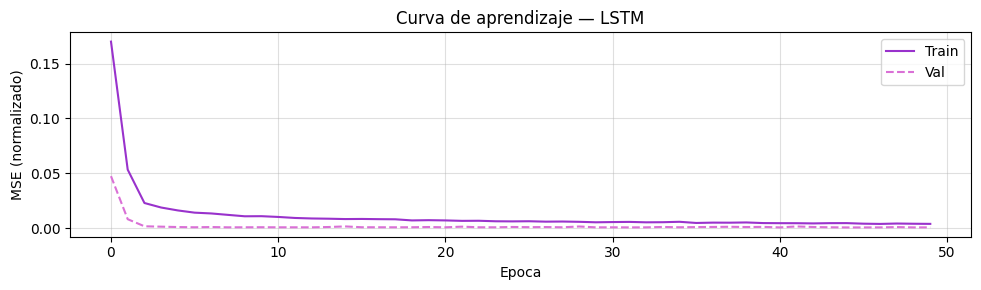

In [92]:
plt.figure(figsize=(10, 3))
plt.plot(hist_train_lstm, label='Train', color='darkorchid')
plt.plot(hist_val_lstm,   label='Val',   color='orchid', linestyle='--')
plt.title('Curva de aprendizaje — LSTM')
plt.xlabel('Epoca'); plt.ylabel('MSE (normalizado)')
plt.legend(); plt.grid(True, alpha=0.4); plt.tight_layout(); plt.show()

## 6. Modelo GRU

La GRU simplifica la LSTM con **un solo estado oculto** $h_t$, sin estado de celda $c_t$.
Usa 2 puertas (update + reset) en lugar de 4, reduciendo los parametros ~25%.

```
Entrada : (batch, 50, 1)
    ↓
nn.GRU(input=1, hidden=64, layers=2, dropout=0.2)
    |_ devuelve: out, h_n   <- SIN c_n (no hay estado de celda)
out[:, -1, :]  → ultimo paso temporal  (batch, 64)
    ↓
nn.Linear(64 → 1)
    ↓
Salida : (batch, 1)
```

In [93]:
class GRUModel(nn.Module):
    """
    GRU de 2 capas para prediccion multi-paso (N_OUT = 10 pasos adelante).

    Diferencia critica vs LSTM:
    nn.GRU NO tiene estado de celda (c_t).
    El forward() recibe solo h_n directamente — NO una tupla (h_n, c_n).
    """
    def __init__(self, input_size=1, hidden_size=32, num_layers=2, dropout=0.4, n_out=n_out):
        super().__init__()
        self.gru = nn.GRU(
            input_size  = input_size,
            hidden_size = hidden_size,
            num_layers  = num_layers,
            dropout     = dropout,
            batch_first = True           # (batch, seq, features)
        )
        self.dropout_final = nn.Dropout(dropout)

        self.fc = nn.Linear(hidden_size, n_out)  # salida: N_OUT pasos adelante

    def forward(self, x):
        # x    : (batch, n_steps, 1)
        # out  : (batch, n_steps, hidden_size)
        # h_n  : (num_layers, batch, hidden_size)  <- solo UN estado, no tupla
        out, h_n = self.gru(x)            # <- GRU devuelve h_n directamente (sin c_n)
        last = out[:, -1, :]              # ultimo paso temporal (batch, hidden)
        
        last_drop = self.dropout_final(last)
        return self.fc(last_drop)              # (batch, N_OUT)


gru_model = GRUModel()
print(gru_model)
params_gru = contar_parametros(gru_model)
print(f'\nParametros entrenables (GRU)  : {params_gru:,}')

with torch.no_grad():
    out_test = gru_model(torch.randn(8, n_steps, 1))
    print(f'Verificacion dimensiones      : entrada (8,{n_steps},1) -> salida {out_test.shape}  [esperado: (8,{n_out})]')


GRUModel(
  (gru): GRU(1, 32, num_layers=2, batch_first=True, dropout=0.4)
  (dropout_final): Dropout(p=0.4, inplace=False)
  (fc): Linear(in_features=32, out_features=10, bias=True)
)

Parametros entrenables (GRU)  : 10,026
Verificacion dimensiones      : entrada (8,20,1) -> salida torch.Size([8, 10])  [esperado: (8,10)]


In [94]:
hist_train_gru, hist_val_gru = fit(gru_model, dataloader, epochs=50)

GRUModel  loss 0.00314  val 0.00073: 100%|██████████| 50/50 [00:07<00:00,  6.98it/s]


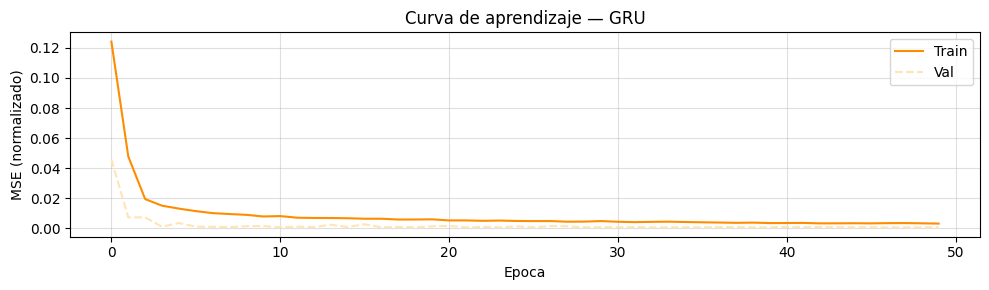

In [95]:
plt.figure(figsize=(10, 3))
plt.plot(hist_train_gru, label='Train', color='darkorange')
plt.plot(hist_val_gru,   label='Val',   color='moccasin', linestyle='--')
plt.title('Curva de aprendizaje — GRU')
plt.xlabel('Epoca'); plt.ylabel('MSE (normalizado)')
plt.legend(); plt.grid(True, alpha=0.4); plt.tight_layout(); plt.show()

## 7. Evaluacion Desnormalizada en BRL

> **Regla de correccion de escala (aplicada aqui):**  
> Se llama a `scaler.inverse_transform()` sobre **predicciones Y valores reales** antes de calcular cualquier metrica. MSE y RMSE se expresan en Reales Brasileños (BRL), nunca en la escala [0, 1].

=== Predicciones LSTM (escala normalizada) ===


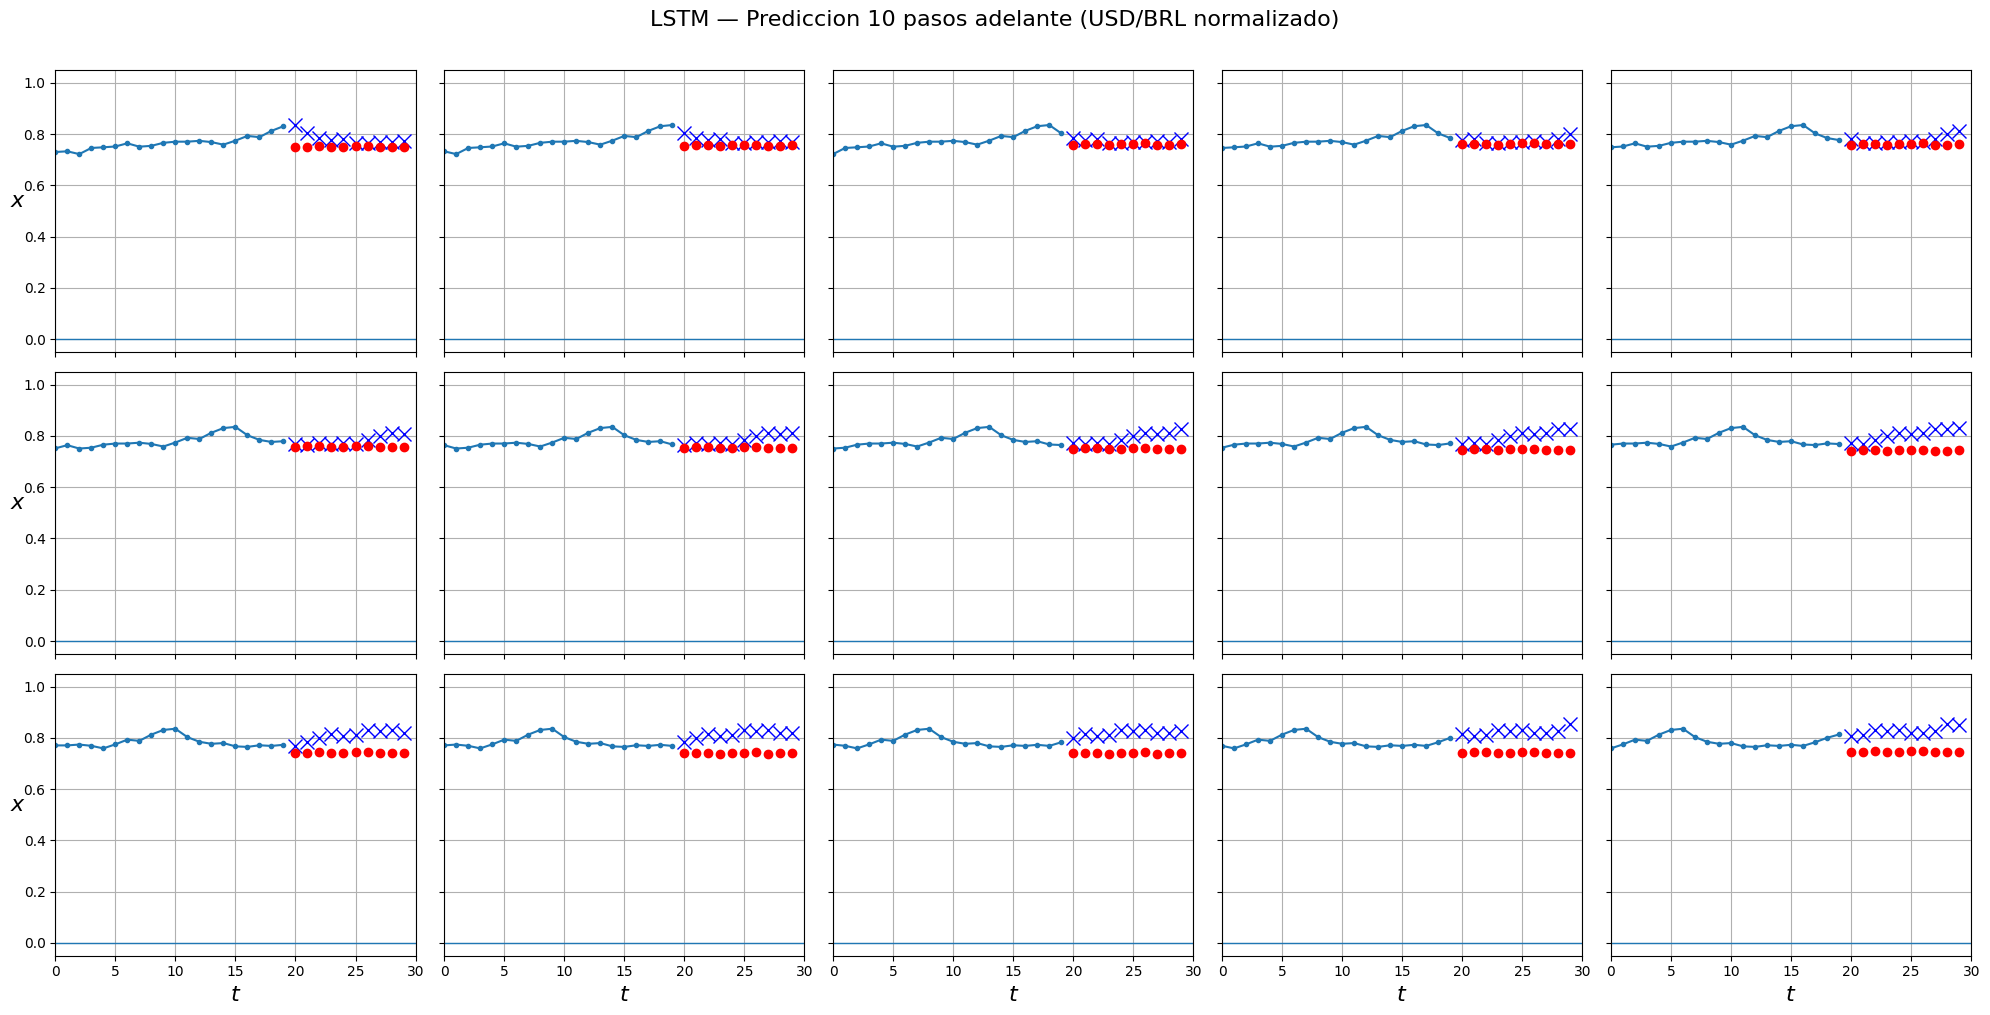

=== Predicciones GRU (escala normalizada) ===


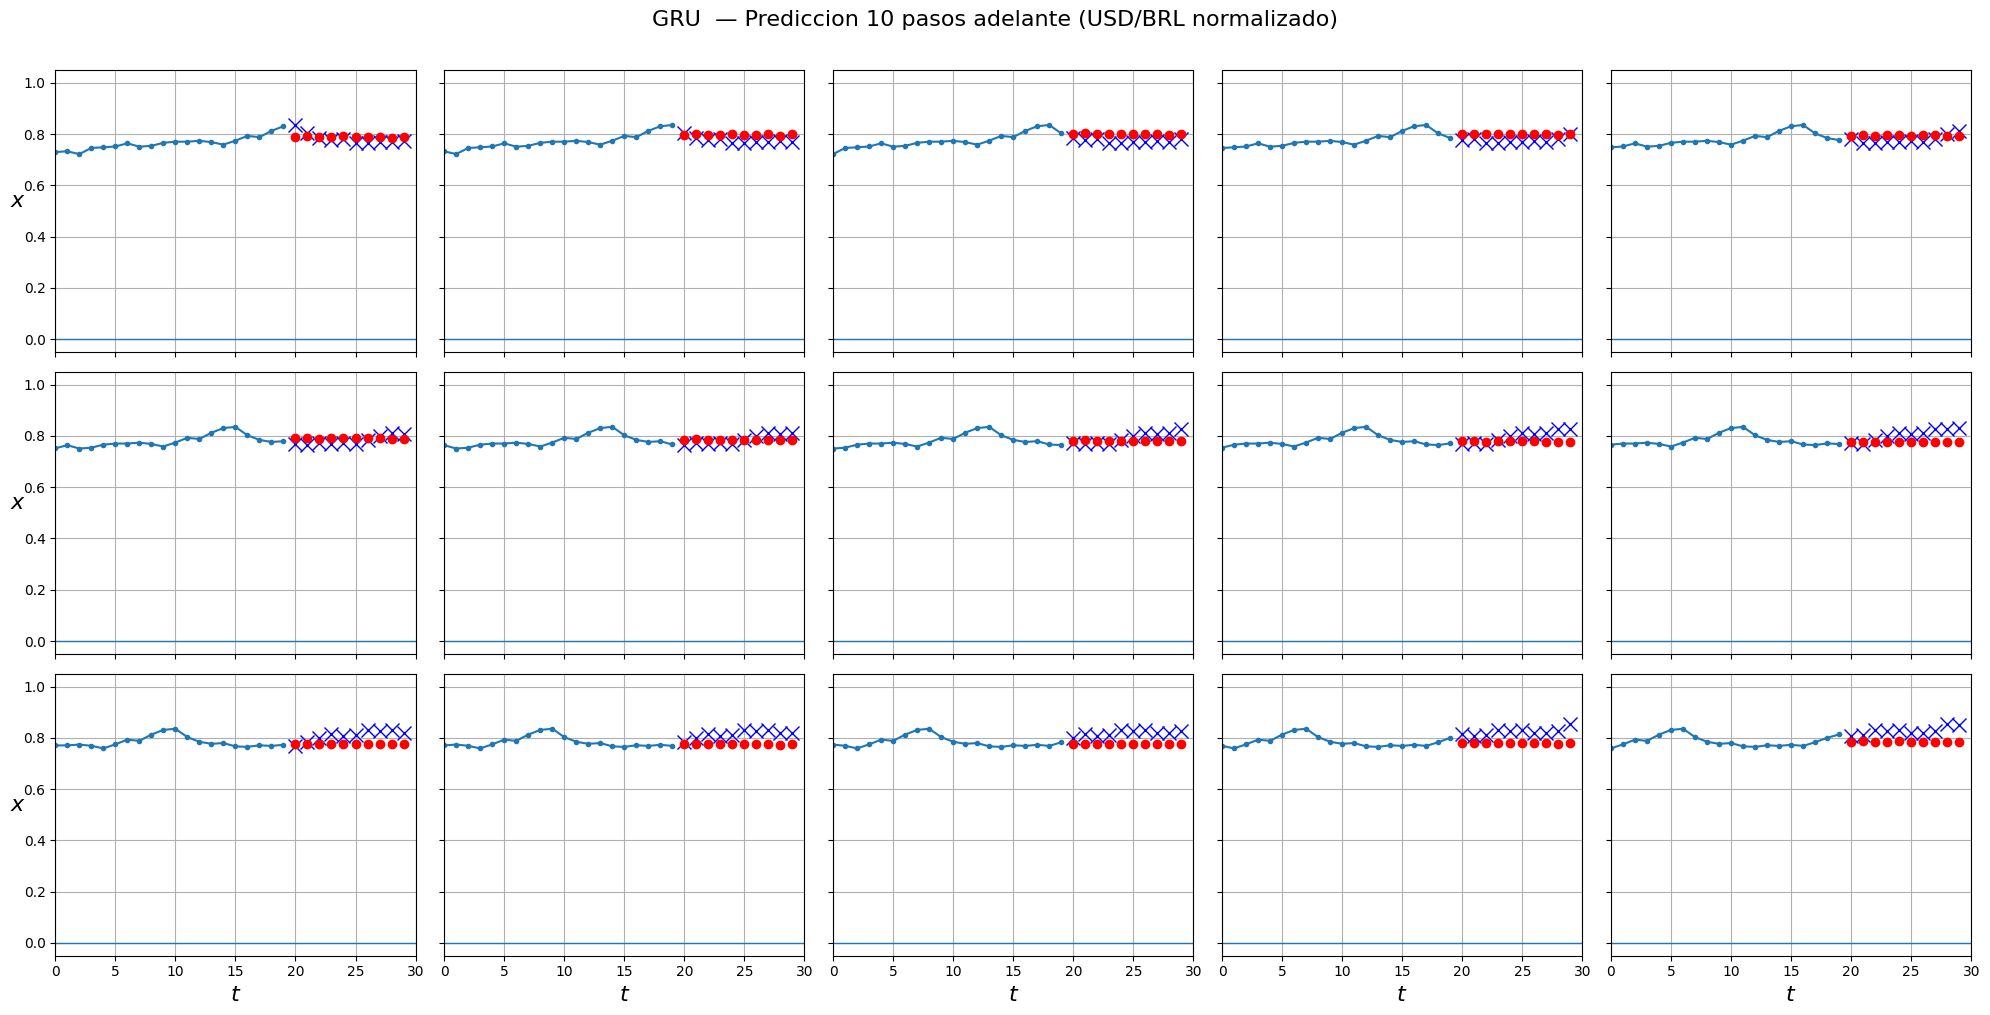


Errores en escala real (BRL) — paso t+1 — post inverse_transform():
  Naive  -> MSE: 0.001910  |  RMSE: 0.0437 BRL
  LSTM   -> MSE: 0.047704  |  RMSE: 0.2184 BRL
  GRU    -> MSE: 0.007650  |  RMSE: 0.0875 BRL


In [96]:
# ── 1. Predicciones en escala normalizada [0, 1] ─────────────────────────────
y_pred_lstm_norm = predict(lstm_model, dataloader['test'])   # (N_test, N_OUT)
y_pred_gru_norm  = predict(gru_model,  dataloader['test'])   # (N_test, N_OUT)

# X_test en 2D para plot_series: (N_test, n_steps)
X_test_2d = X_test[:, :, 0]   # quitar dim de features

# ── 2. Grilla 3x5 — estilo cuadernillo base ───────────────────────────────────
print('=== Predicciones LSTM (escala normalizada) ===')
plot_series(X_test_2d, y_test, y_pred_lstm_norm,
            title='LSTM — Prediccion 10 pasos adelante (USD/BRL normalizado)')

print('=== Predicciones GRU (escala normalizada) ===')
plot_series(X_test_2d, y_test, y_pred_gru_norm,
            title='GRU  — Prediccion 10 pasos adelante (USD/BRL normalizado)')

# ── 3. CORRECCION DE ESCALA: inverse_transform -> BRL ────────────────────────
# Metricas sobre el primer paso adelante (t+1) para comparacion justa con Naive
y_test_brl       = desnormalizar(y_test[:, 0])              # paso t+1 real en BRL
y_pred_lstm_brl  = desnormalizar(y_pred_lstm_norm[:, 0])    # LSTM paso t+1 en BRL
y_pred_gru_brl   = desnormalizar(y_pred_gru_norm[:, 0])     # GRU  paso t+1 en BRL

# Naive: ultimo valor de la ventana (X_test[:, -1, 0])
y_pred_naive_norm = X_test[:, -1, 0].reshape(-1, 1)
y_pred_naive_brl  = desnormalizar(y_pred_naive_norm.flatten())

# ── 4. MSE y RMSE en BRL (paso t+1) ──────────────────────────────────────────
mse_naive  = mean_squared_error(y_test_brl, y_pred_naive_brl)
mse_lstm   = mean_squared_error(y_test_brl, y_pred_lstm_brl)
mse_gru    = mean_squared_error(y_test_brl, y_pred_gru_brl)

rmse_naive = np.sqrt(mse_naive)
rmse_lstm  = np.sqrt(mse_lstm)
rmse_gru   = np.sqrt(mse_gru)

print('\nErrores en escala real (BRL) — paso t+1 — post inverse_transform():')
print(f'  Naive  -> MSE: {mse_naive:.6f}  |  RMSE: {rmse_naive:.4f} BRL')
print(f'  LSTM   -> MSE: {mse_lstm:.6f}  |  RMSE: {rmse_lstm:.4f} BRL')
print(f'  GRU    -> MSE: {mse_gru:.6f}  |  RMSE: {rmse_gru:.4f} BRL')


## 8. Grafica Comparativa: LSTM vs GRU vs Real

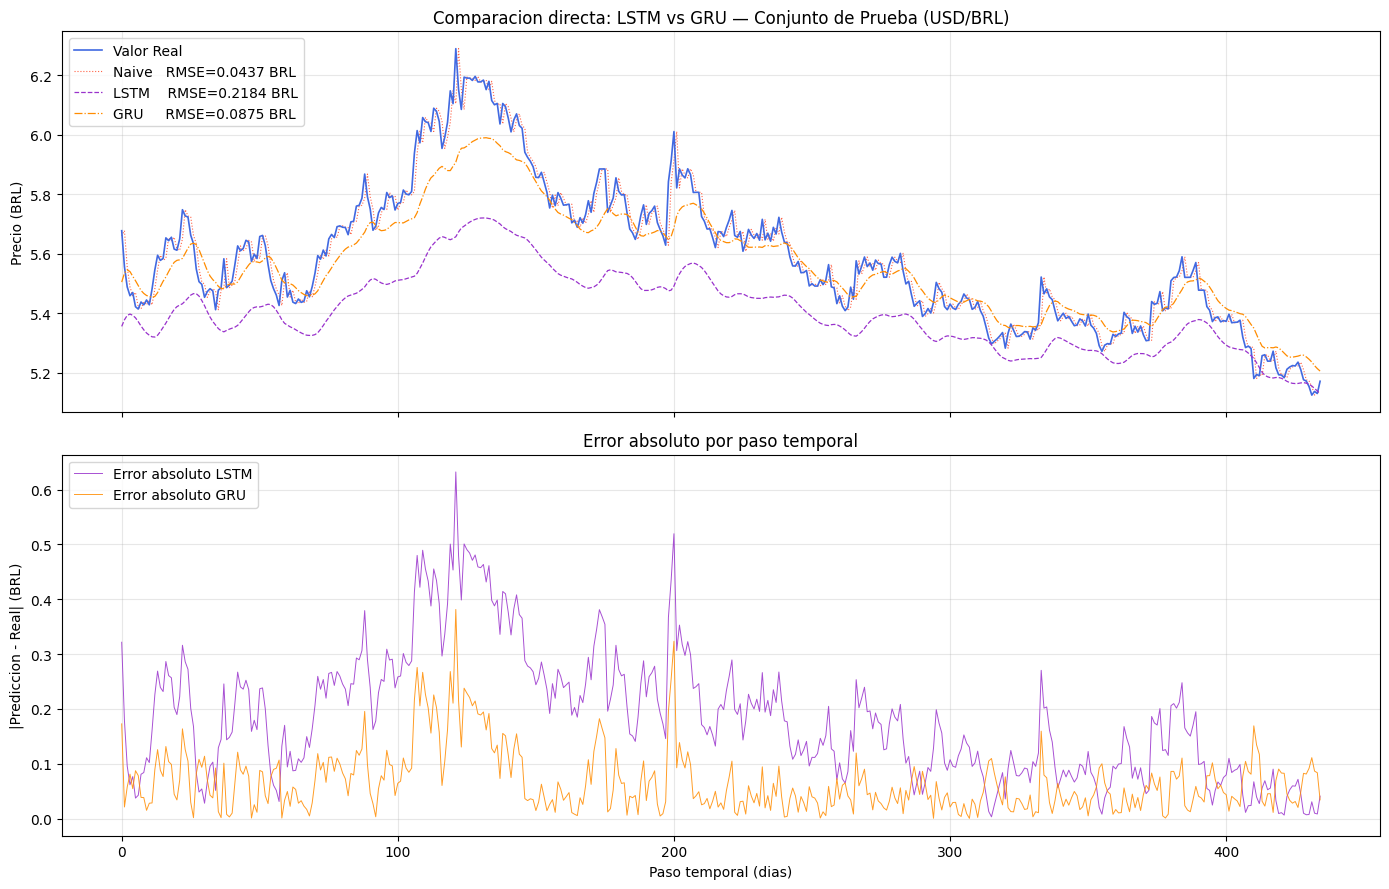

In [97]:
fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)

# Panel superior: predicciones superpuestas sobre valores reales
ax = axes[0]
ax.plot(y_test_brl,       label='Valor Real',
        color='royalblue',  linewidth=1.2, zorder=3)
ax.plot(y_pred_naive_brl, label=f'Naive   RMSE={rmse_naive:.4f} BRL',
        color='tomato',     linewidth=0.8, linestyle=':',  zorder=2)
ax.plot(y_pred_lstm_brl,  label=f'LSTM    RMSE={rmse_lstm:.4f} BRL',
        color='darkorchid', linewidth=0.9, linestyle='--', zorder=4)
ax.plot(y_pred_gru_brl,   label=f'GRU     RMSE={rmse_gru:.4f} BRL',
        color='darkorange', linewidth=0.9, linestyle='-.', zorder=4)
ax.set_title('Comparacion directa: LSTM vs GRU — Conjunto de Prueba (USD/BRL)')
ax.set_ylabel('Precio (BRL)')
ax.legend(loc='upper left'); ax.grid(True, alpha=0.3)

# Panel inferior: error absoluto por modelo
ax2 = axes[1]
ax2.plot(np.abs(y_test_brl - y_pred_lstm_brl),
         label='Error absoluto LSTM', color='darkorchid', linewidth=0.7, alpha=0.85)
ax2.plot(np.abs(y_test_brl - y_pred_gru_brl),
         label='Error absoluto GRU',  color='darkorange',  linewidth=0.7, alpha=0.85)
ax2.set_title('Error absoluto por paso temporal')
ax2.set_xlabel('Paso temporal (dias)')
ax2.set_ylabel('|Prediccion - Real| (BRL)')
ax2.legend(loc='upper left'); ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

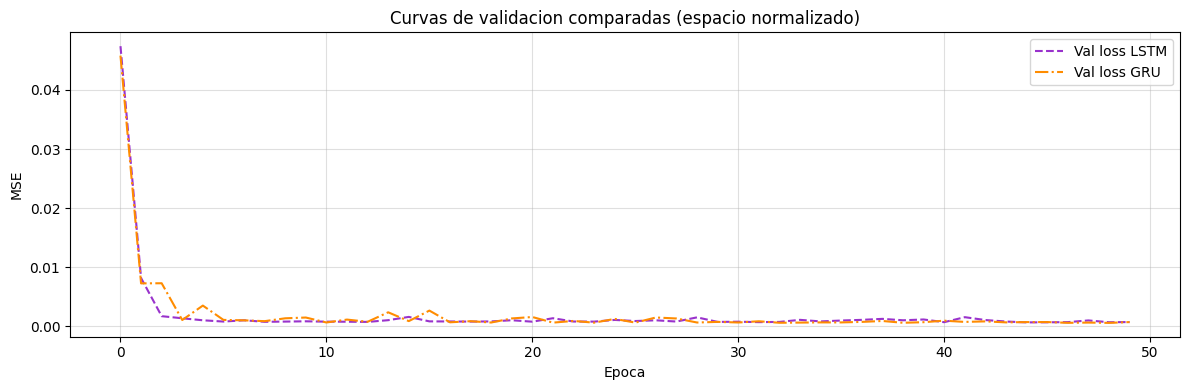

In [98]:
# Curvas de validacion comparadas
plt.figure(figsize=(12, 4))
plt.plot(hist_val_lstm, label='Val loss LSTM', color='darkorchid', linestyle='--')
plt.plot(hist_val_gru,  label='Val loss GRU',  color='darkorange',  linestyle='-.')
plt.title('Curvas de validacion comparadas (espacio normalizado)')
plt.xlabel('Epoca'); plt.ylabel('MSE')
plt.legend(); plt.grid(True, alpha=0.4); plt.tight_layout(); plt.show()

## 9. Tabla de Resultados Finales

In [99]:
ahorro_pct = (1 - params_gru / params_lstm) * 100
ganador    = 'LSTM' if rmse_lstm <= rmse_gru else 'GRU'
mejor_rmse = min(rmse_lstm, rmse_gru)

sep  = '=' * 68
sep2 = '-' * 68

print(sep)
print(f'  {"TABLA COMPARATIVA FINAL --- USD/BRL":^64}')
print(sep)
print(f'  {"Modelo":<10}  {"RMSE (BRL)":>12}  {"MSE (BRL^2)":>14}  {"Parametros":>12}')
print(sep2)
print(f'  {"Naive":<10}  {rmse_naive:>12.4f}  {mse_naive:>14.6f}  {"---":>12}')
print(f'  {"LSTM":<10}  {rmse_lstm:>12.4f}  {mse_lstm:>14.6f}  {params_lstm:>12,}')
print(f'  {"GRU":<10}  {rmse_gru:>12.4f}  {mse_gru:>14.6f}  {params_gru:>12,}')
print(sep)
print(f'  Mejor modelo      : {ganador}  (RMSE = {mejor_rmse:.4f} BRL)')
print(f'  Ahorro de params  : GRU usa {ahorro_pct:.1f}% menos parametros que LSTM')
print(sep)



                TABLA COMPARATIVA FINAL --- USD/BRL               
  Modelo        RMSE (BRL)     MSE (BRL^2)    Parametros
--------------------------------------------------------------------
  Naive             0.0437        0.001910           ---
  LSTM              0.2184        0.047704        13,258
  GRU               0.0875        0.007650        10,026
  Mejor modelo      : GRU  (RMSE = 0.0875 BRL)
  Ahorro de params  : GRU usa 24.4% menos parametros que LSTM


---
## 10. Extensión — Predicción a 30 Pasos

Repetimos el experimento completo con `N_OUT2 = 30` para comparar cómo
escala cada arquitectura cuando el horizonte de predicción se triplica.

| Horizonte | Modelos | DataLoader |
|---|---|---|
| 10 pasos | `lstm_model`, `gru_model` | `dataloader` |
| 30 pasos | `lstm_model30`, `gru_model30` | `dataloader30` |


In [100]:
# ── Ventanas y DataLoaders para N_OUT2 = 30 ─────────────────────────────────
n_out2 = 30

X_all30, y_all30 = crear_ventanas(precios_norm, n_steps, n_out2)
print(f'X_all30 : {X_all30.shape}  -> (muestras, n_steps, features)')
print(f'y_all30 : {y_all30.shape}  -> (muestras, {n_out2})  [salida 30 pasos]')

n_total30 = len(X_all30)
n_train30 = int(n_total30 * 0.70)
n_val30   = int(n_total30 * 0.15)

X_train30, y_train30 = X_all30[:n_train30],                  y_all30[:n_train30]
X_val30,   y_val30   = X_all30[n_train30:n_train30+n_val30], y_all30[n_train30:n_train30+n_val30]
X_test30,  y_test30  = X_all30[n_train30+n_val30:],          y_all30[n_train30+n_val30:]

print(f'\nTrain30 : {X_train30.shape[0]:>5} muestras')
print(f'Val30   : {X_val30.shape[0]:>5} muestras')
print(f'Test30  : {X_test30.shape[0]:>5} muestras')

dataloader30 = {
    'train': DataLoader(TimeSeriesDataset(X_train30, y_train30), shuffle=True,  batch_size=batch_size),
    'eval' : DataLoader(TimeSeriesDataset(X_val30,   y_val30),   shuffle=False, batch_size=batch_size),
    'test' : DataLoader(TimeSeriesDataset(X_test30),              shuffle=False, batch_size=batch_size),
}

Xb30, yb30 = next(iter(dataloader30['train']))
print(f'\nBatch X30 : {Xb30.shape}  -> (batch, n_steps, features)')
print(f'Batch y30 : {yb30.shape}  -> (batch, {n_out2})')


X_all30 : (2873, 20, 1)  -> (muestras, n_steps, features)
y_all30 : (2873, 30)  -> (muestras, 30)  [salida 30 pasos]

Train30 :  2011 muestras
Val30   :   430 muestras
Test30  :   432 muestras

Batch X30 : torch.Size([64, 20, 1])  -> (batch, n_steps, features)
Batch y30 : torch.Size([64, 30])  -> (batch, 30)


### 10.1 Definición de Modelos — Horizonte 30

La arquitectura es **idéntica** a la de 10 pasos; solo cambia la dimensión
de salida de la capa lineal: `nn.Linear(64 → 30)`.


In [101]:

class GRUModel30(nn.Module):
    """GRU 2 capas — salida 30 pasos adelante."""
    def __init__(self, input_size=1, hidden_size=32, num_layers=2, dropout=0.4):
        super().__init__()
        self.gru = nn.GRU(input_size, hidden_size, num_layers,
                          dropout=dropout, batch_first=True)
        self.fc = nn.Linear(hidden_size, n_out2)  # 64 -> 30

    def forward(self, x):
        out, h_n = self.gru(x)
        return self.fc(out[:, -1, :])   # (batch, 30)

gru_model30  = GRUModel30()

params_gru30  = contar_parametros(gru_model30)
print(f'Parametros GRU-30  : {params_gru30:,}')

with torch.no_grad():
    o = gru_model30(torch.randn(8, n_steps, 1))
    print(f'GRU-30  dim check  : entrada (8,{n_steps},1) -> salida {o.shape}  [esperado: (8,{n_out2})]')


Parametros GRU-30  : 10,686
GRU-30  dim check  : entrada (8,20,1) -> salida torch.Size([8, 30])  [esperado: (8,30)]


### 10.2 Entrenamiento — Horizonte 30


In [102]:
hist_train_gru30, hist_val_gru30 = fit(gru_model30, dataloader30, epochs=50)


GRUModel30  loss 0.00234  val 0.00351: 100%|██████████| 50/50 [00:06<00:00,  7.20it/s]


### 10.3 Evaluación Visual — Grilla 3×5 (30 pasos)

Cada subgráfica muestra:
- **Línea azul** — ventana de entrada (50 pasos históricos)
- **`bx` azul** — valor real (30 pasos futuros)
- **`ro` rojo** — predicción del modelo (30 pasos futuros)


=== Predicciones GRU-30 (escala normalizada) ===


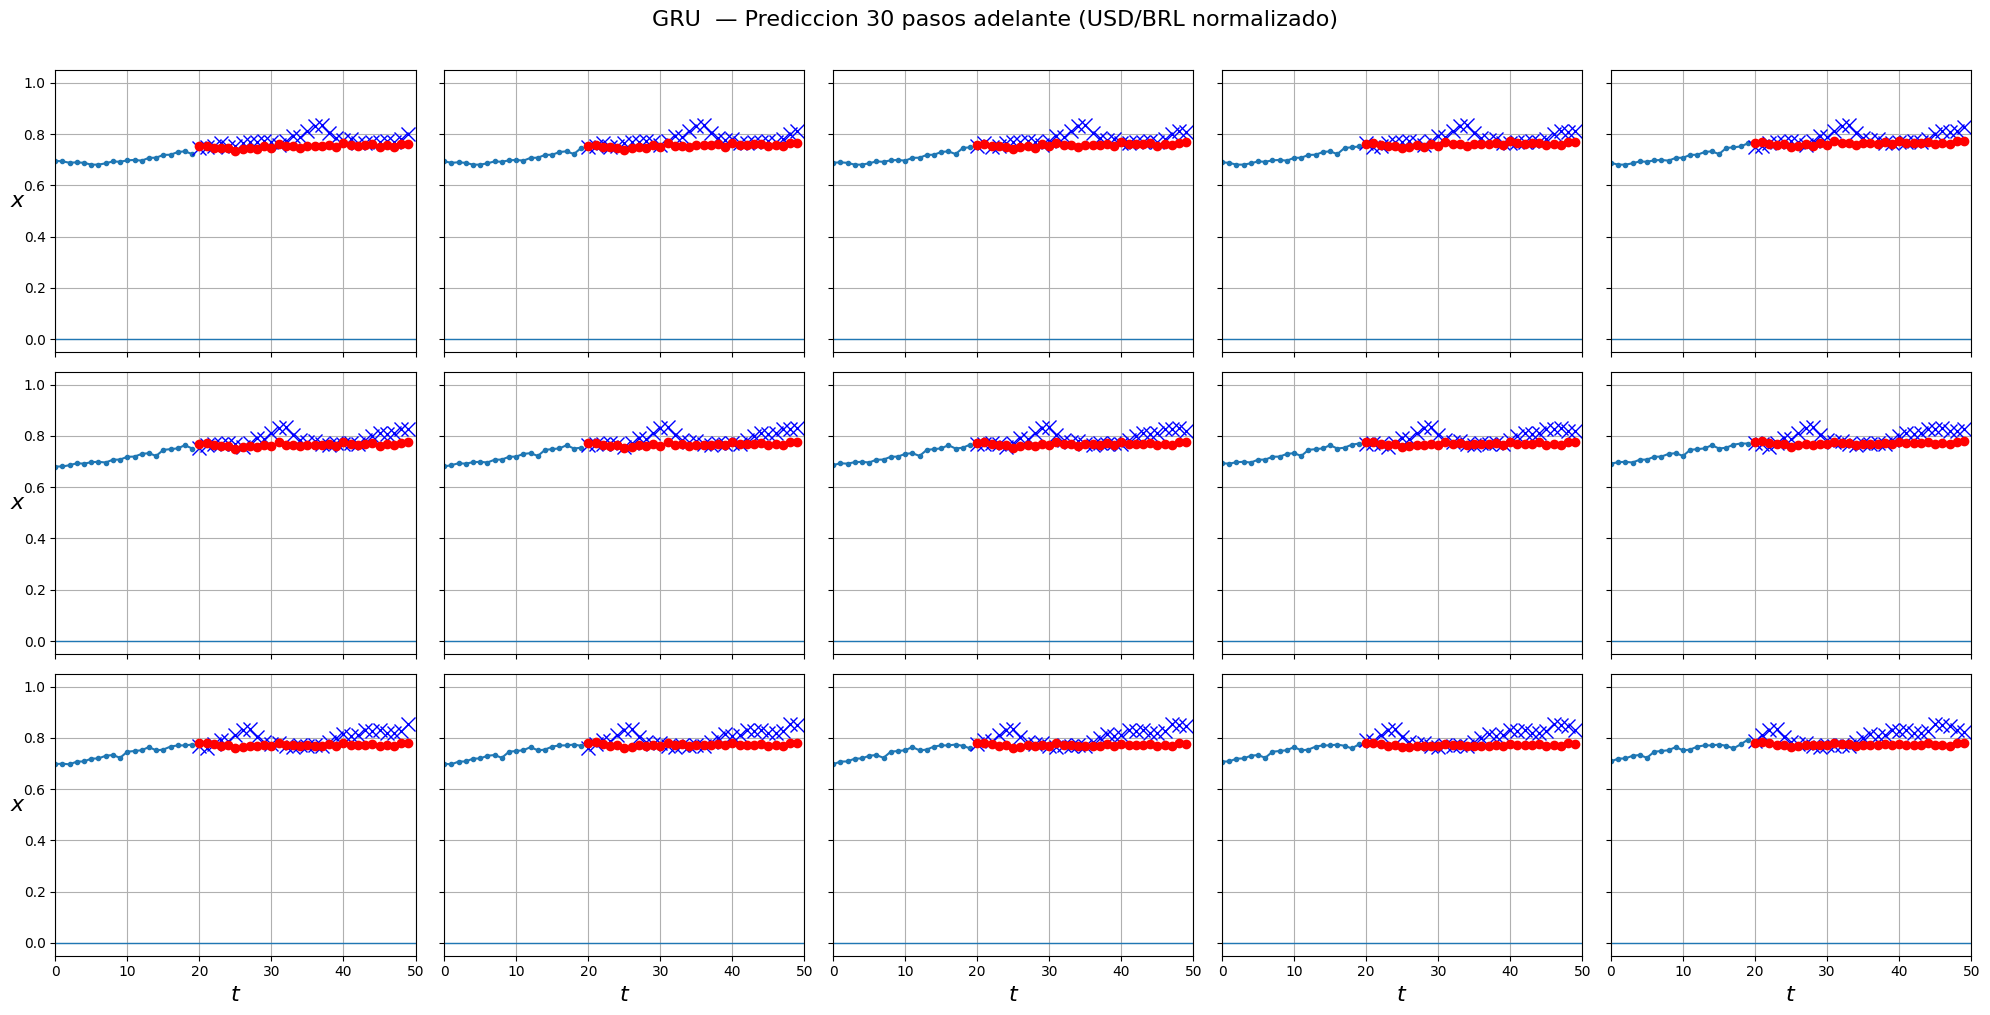


Errores en BRL — paso t+1 (horizonte 30):
  GRU-30  -> MSE: 0.019004  |  RMSE: 0.1379 BRL


In [103]:
# ── Predicciones ────────────────────────────────────────────────────────────
y_pred_gru30_norm  = predict(gru_model30,  dataloader30['test'])  # (N_test, 30)

X_test30_2d = X_test30[:, :, 0]   # (N_test, n_steps)


# ── Grilla 3x5 — GRU 30 ──────────────────────────────────────────────────────
print('=== Predicciones GRU-30 (escala normalizada) ===')
plot_series(X_test30_2d, y_test30, y_pred_gru30_norm,
            title='GRU  — Prediccion 30 pasos adelante (USD/BRL normalizado)')

# ── Metricas BRL sobre el paso t+1 ───────────────────────────────────────────
y_test30_brl      = desnormalizar(y_test30[:, 0])
y_pred_gru30_brl  = desnormalizar(y_pred_gru30_norm[:, 0])

mse_gru30   = mean_squared_error(y_test30_brl, y_pred_gru30_brl)
rmse_gru30  = np.sqrt(mse_gru30)

print(f'\nErrores en BRL — paso t+1 (horizonte 30):')
print(f'  GRU-30  -> MSE: {mse_gru30:.6f}  |  RMSE: {rmse_gru30:.4f} BRL')


### 10.4 Tabla Comparativa Final — 10 Pasos vs 30 Pasos


In [104]:
sep  = '=' * 78
sep2 = '-' * 78

print(sep)
print(f'  {"TABLA COMPARATIVA: HORIZONTE 10 vs 30 PASOS — USD/BRL":^74}')
print(sep)
print(f'  {"Modelo":<14}  {"Horizonte":>10}  {"RMSE (BRL)":>12}  {"MSE (BRL^2)":>14}  {"Params":>10}')
print(sep2)

rows = [
    ('Naive',    10, rmse_naive,  mse_naive,  None),
    ('LSTM',     10, rmse_lstm,   mse_lstm,   params_lstm),
    ('GRU',      10, rmse_gru,    mse_gru,    params_gru),
    ('GRU-30',   30, rmse_gru30,  mse_gru30,  params_gru30),
]

prev_h = None
for nombre, horizonte, rmse, mse, params in rows:
    if prev_h is not None and horizonte != prev_h:
        print(sep2)
    p_str = f'{params:>10,}' if params is not None else f'{"---":>10}'
    print(f'  {nombre:<14}  {horizonte:>10}  {rmse:>12.4f}  {mse:>14.6f}  {p_str}')
    prev_h = horizonte

print(sep)
print('  * RMSE y MSE calculados sobre el paso t+1 en escala real (BRL).')
print(f'  * Ahorro parametros GRU-30 vs LSTM-30 : {(1-params_gru30/params_lstm30)*100:.1f} %')
print(sep)



            TABLA COMPARATIVA: HORIZONTE 10 vs 30 PASOS — USD/BRL           
  Modelo           Horizonte    RMSE (BRL)     MSE (BRL^2)      Params
------------------------------------------------------------------------------
  Naive                   10        0.0437        0.001910         ---
  LSTM                    10        0.2184        0.047704      13,258
  GRU                     10        0.0875        0.007650      10,026
------------------------------------------------------------------------------
  GRU-30                  30        0.1379        0.019004      10,686
  * RMSE y MSE calculados sobre el paso t+1 en escala real (BRL).
  * Ahorro parametros GRU-30 vs LSTM-30 : 23.2 %
